# Introduction to Monte Carlo Simulation

We will:

- Generate data by simulation of a repeat success / failure experiment
- One experiment consists of many trials and we can store it in a DataFrame
- a random variable summarizes each experiment
- repeating the experiment many times reveals its distribution

## Step 1: Define the experiment

We consider an experiment with $n$ independent trials.

- Each trial is a success (1) with probability $p$
- Each trial is a failure (0) with probability $1 - p$

We define the random variable

$$
X = \text{number of successes in } n \text{ trials}
$$

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

rng = np.random.default_rng(391) # 391 is just a seed for the random number generator, default_rng is 0 to 1

n = 10
p = 0.5
Nsim = 1000

uniform_rand = rng.random(size=(Nsim, n))
success = uniform_rand < p

## Step 2: Simulate the underlying process

Each experiment consists of $n$ trials.

We will store the results as a table:

- Each row = one experiment
- Each column = one trial

In [8]:
df = pd.DataFrame(
    success,
    columns=[f"trial_{j+1}" for j in range(n)]
)

df.head()

,trial_1,trial_2,trial_3,trial_4,trial_5,trial_6,trial_7,trial_8,trial_9,trial_10
0,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,True,True,False,True,True,False
2,True,True,False,False,False,False,True,False,True,True
3,True,False,True,False,False,True,True,True,False,True
4,True,False,True,False,False,True,True,False,False,False


## Step 3: Define the random variable

We define indicator variables for each trial:

$$
Y_i =
\begin{cases}
1 & \text{if trial } i \text{ is a success} \\
0 & \text{if trial } i \text{ is a failure}
\end{cases}
$$

The random variable is

$$
X = \sum_{i=1}^{n} Y_i
$$

In [9]:
df["X"] = success.sum(axis=1)
df[["X"]].head()

,X
0,2
1,4
2,5
3,6
4,4


## Step 5: Estimate the PMF from data

We estimate:

$$
P(X = k) \approx \frac{\text{number of experiments with } X = k}{\text{total number of experiments}}
$$

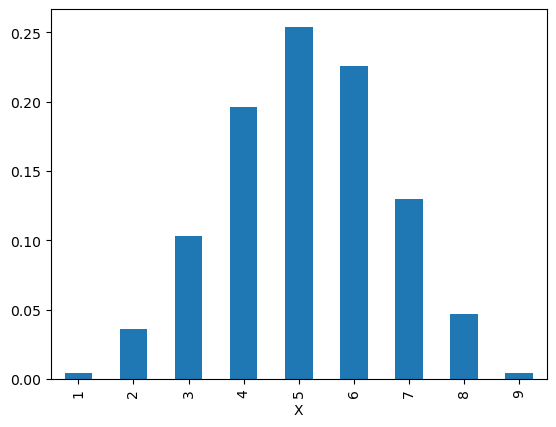

In [18]:
pmf_empirical = df["X"].value_counts(normalize=True).sort_index()
ax_pmf = pmf_empirical.plot(kind="bar")

## Step 6: Analytical result

If trials are independent, then $X$ follows a binomial distribution:

$$
P(X = k) = \binom{n}{k} p^k (1 - p)^{n-k}
$$

In [19]:
from scipy.stats import binom

k_values = np.arange(n + 1)
pmf_binom = pd.Series(
    binom.pmf(k_values, n, p),
    index=k_values
)

## Step 7: Compare empirical and exact distributions

<Axes: >

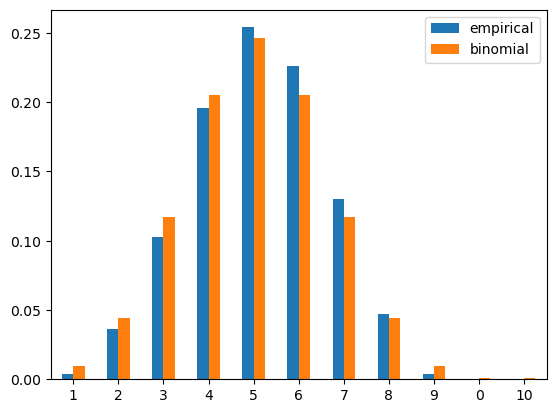

In [21]:
comparison = pd.concat([pmf_empirical, pmf_binom], axis=1)
comparison.columns = ["empirical", "binomial"]
comparison.plot(kind="bar", rot=0)

## Step 8: Convergence

As the number of experiments increases,

$$
\text{empirical distribution} \rightarrow \text{true distribution}
$$

Try changing:

- $N_{\text{sim}} = 100$
- $N_{\text{sim}} = 1000$
- $N_{\text{sim}} = 10000$

## Summary

- We simulated the underlying trial-by-trial process
- Each row represents one outcome
- The random variable $X$ summarizes each outcome
- Repeated experiments reveal the distribution of $X$
- The empirical PMF matches the binomial model